# nb01 · PyBaMM 入门与三模型对比

本 notebook 是电池建模系列的第一篇，目标：

1. 跑通最小可运行示例：默认参数下 1C 恒流放电，绘制端电压随时间变化。
2. 分别构建 **SPM**、**SPMe**、**DFN** 三种锂离子模型，叠加对比放电电压曲线与求解耗时。
3. 理解三者的物理差异与「精度 vs 计算量」权衡。

| 模型 | 全称 | 颗粒/电解液 | 速度 | 精度 |
| --- | --- | --- | --- | --- |
| SPM | Single Particle Model | 每电极单颗粒，无电解液动力学 | 最快 | 最低 |
| SPMe | SPM with electrolyte | 单颗粒 + 电解液 | 中 | 中 |
| DFN | Doyle-Fuller-Newman (P2D) | 多颗粒 + 完整电化学 | 最慢 | 最高 |

## 0. 环境与导入

统一在此导入 pybamm / numpy / matplotlib，并设置绘图风格。后续 notebook 复用同一模板。

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pybamm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

print("PyBaMM 版本:", pybamm.__version__)

PyBaMM 版本: 26.6.1.1


## 1. 最小可运行示例：DFN 1C 放电

三步走：建模型 → 建仿真 → 求解。`sim.solve([0, 3600])` 表示求解 0~3600 秒。

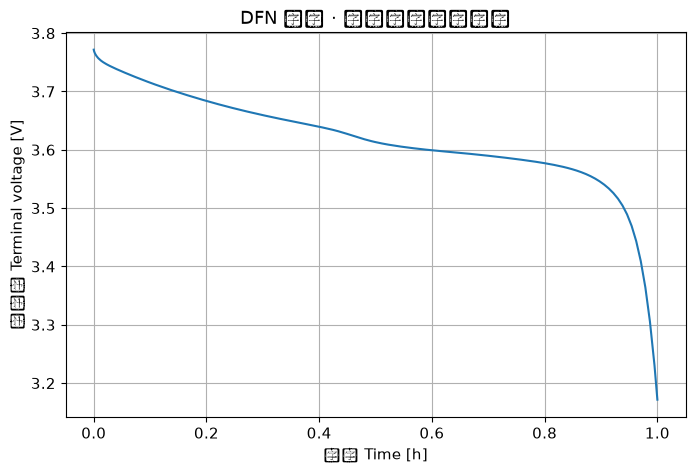

In [2]:
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model)
solution = sim.solve([0, 3600])  # 求解 1 小时（约 1C 放电）

# 提取端电压与时间
t = solution["Time [s]"].entries
V = solution["Terminal voltage [V]"].entries

plt.plot(t / 3600, V)
plt.xlabel("时间 Time [h]")
plt.ylabel("端电压 Terminal voltage [V]")
plt.title("DFN 模型 · 默认参数放电曲线")
plt.show()

## 2. 三模型对比：电压曲线与耗时

用同一组默认参数分别建 SPM / SPMe / DFN，统一放电 1 小时，记录各自求解耗时并叠加电压曲线。

In [3]:
models = {
    "SPM": pybamm.lithium_ion.SPM(),
    "SPMe": pybamm.lithium_ion.SPMe(),
    "DFN": pybamm.lithium_ion.DFN(),
}

solutions = {}
timings = {}
for name, mdl in models.items():
    sim = pybamm.Simulation(mdl)
    t0 = time.perf_counter()
    sol = sim.solve([0, 3600])
    timings[name] = time.perf_counter() - t0
    solutions[name] = sol
    print(f"{name:5s} 求解耗时: {timings[name]*1000:7.1f} ms")

SPM   求解耗时:   179.0 ms
SPMe  求解耗时:   192.5 ms


DFN   求解耗时:   378.8 ms


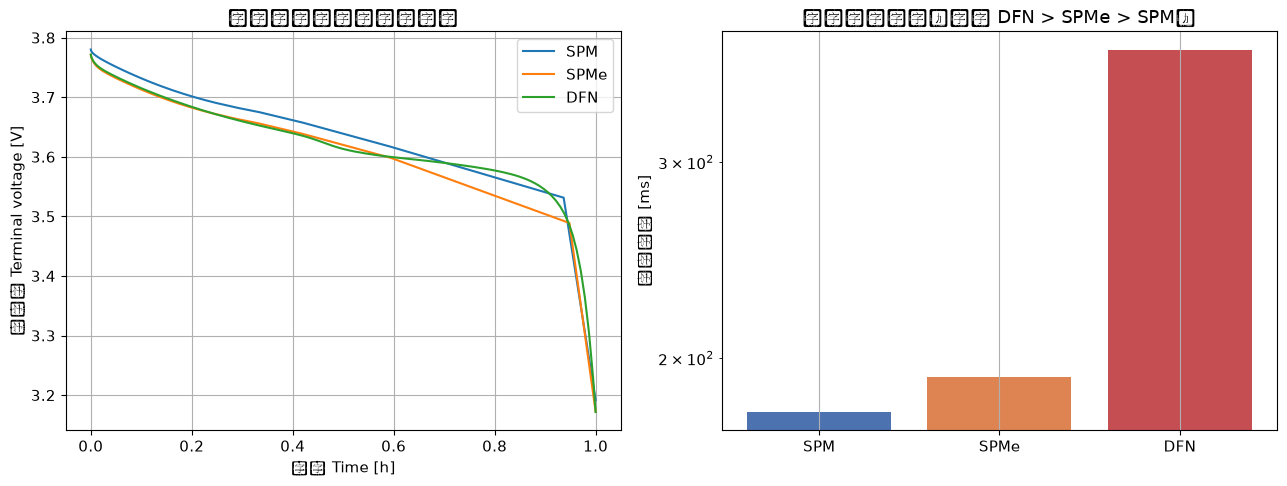

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 左：电压曲线对比
for name, sol in solutions.items():
    ax1.plot(sol["Time [s]"].entries / 3600, sol["Terminal voltage [V]"].entries, label=name)
ax1.set_xlabel("时间 Time [h]")
ax1.set_ylabel("端电压 Terminal voltage [V]")
ax1.set_title("三模型放电电压曲线对比")
ax1.legend()

# 右：求解耗时对比（对数坐标）
names = list(timings.keys())
ax2.bar(names, [timings[n] * 1000 for n in names], color=["#4C72B0", "#DD8452", "#C44E52"])
ax2.set_ylabel("求解耗时 [ms]")
ax2.set_title("求解耗时对比（一般 DFN > SPMe > SPM）")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

## 3. 量化差异：以 DFN 为基准的电压偏差

把 SPM / SPMe 的电压插值到 DFN 的时间网格上，计算与 DFN 的均方根偏差（RMSE），
直观看到「简化模型相对完整模型损失了多少精度」。

In [5]:
t_ref = solutions["DFN"]["Time [s]"].entries
V_ref = solutions["DFN"]["Terminal voltage [V]"].entries

for name in ["SPM", "SPMe"]:
    t_n = solutions[name]["Time [s]"].entries
    V_n = solutions[name]["Terminal voltage [V]"].entries
    V_interp = np.interp(t_ref, t_n, V_n)
    rmse = np.sqrt(np.mean((V_interp - V_ref) ** 2))
    print(f"{name:5s} 相对 DFN 的电压 RMSE: {rmse*1000:6.2f} mV")

SPM   相对 DFN 的电压 RMSE:  18.30 mV
SPMe  相对 DFN 的电压 RMSE:  20.14 mV


## 小结

- PyBaMM 的核心三步：`model = pybamm.lithium_ion.XXX()` → `sim = pybamm.Simulation(model)` → `sim.solve([...])`。
- 求解耗时一般满足 **DFN > SPMe > SPM**；精度顺序相反。
- SPMe 通常是「速度/精度」的良好折中：比 SPM 准很多，又比 DFN 快很多。
- 下一篇 `nb02` 将引入**参数集**与**放电倍率（C-rate）**扫描。